### Task 1 — Image Visualization and RGB Histograms

Python nyelven olvass be öt darab tetszőleges 256x256 pixeles színes képet, jelenítsd meg és jelenítsd meg külön az R, G és B csatornák értékeit hisztogramon. **(4p)**


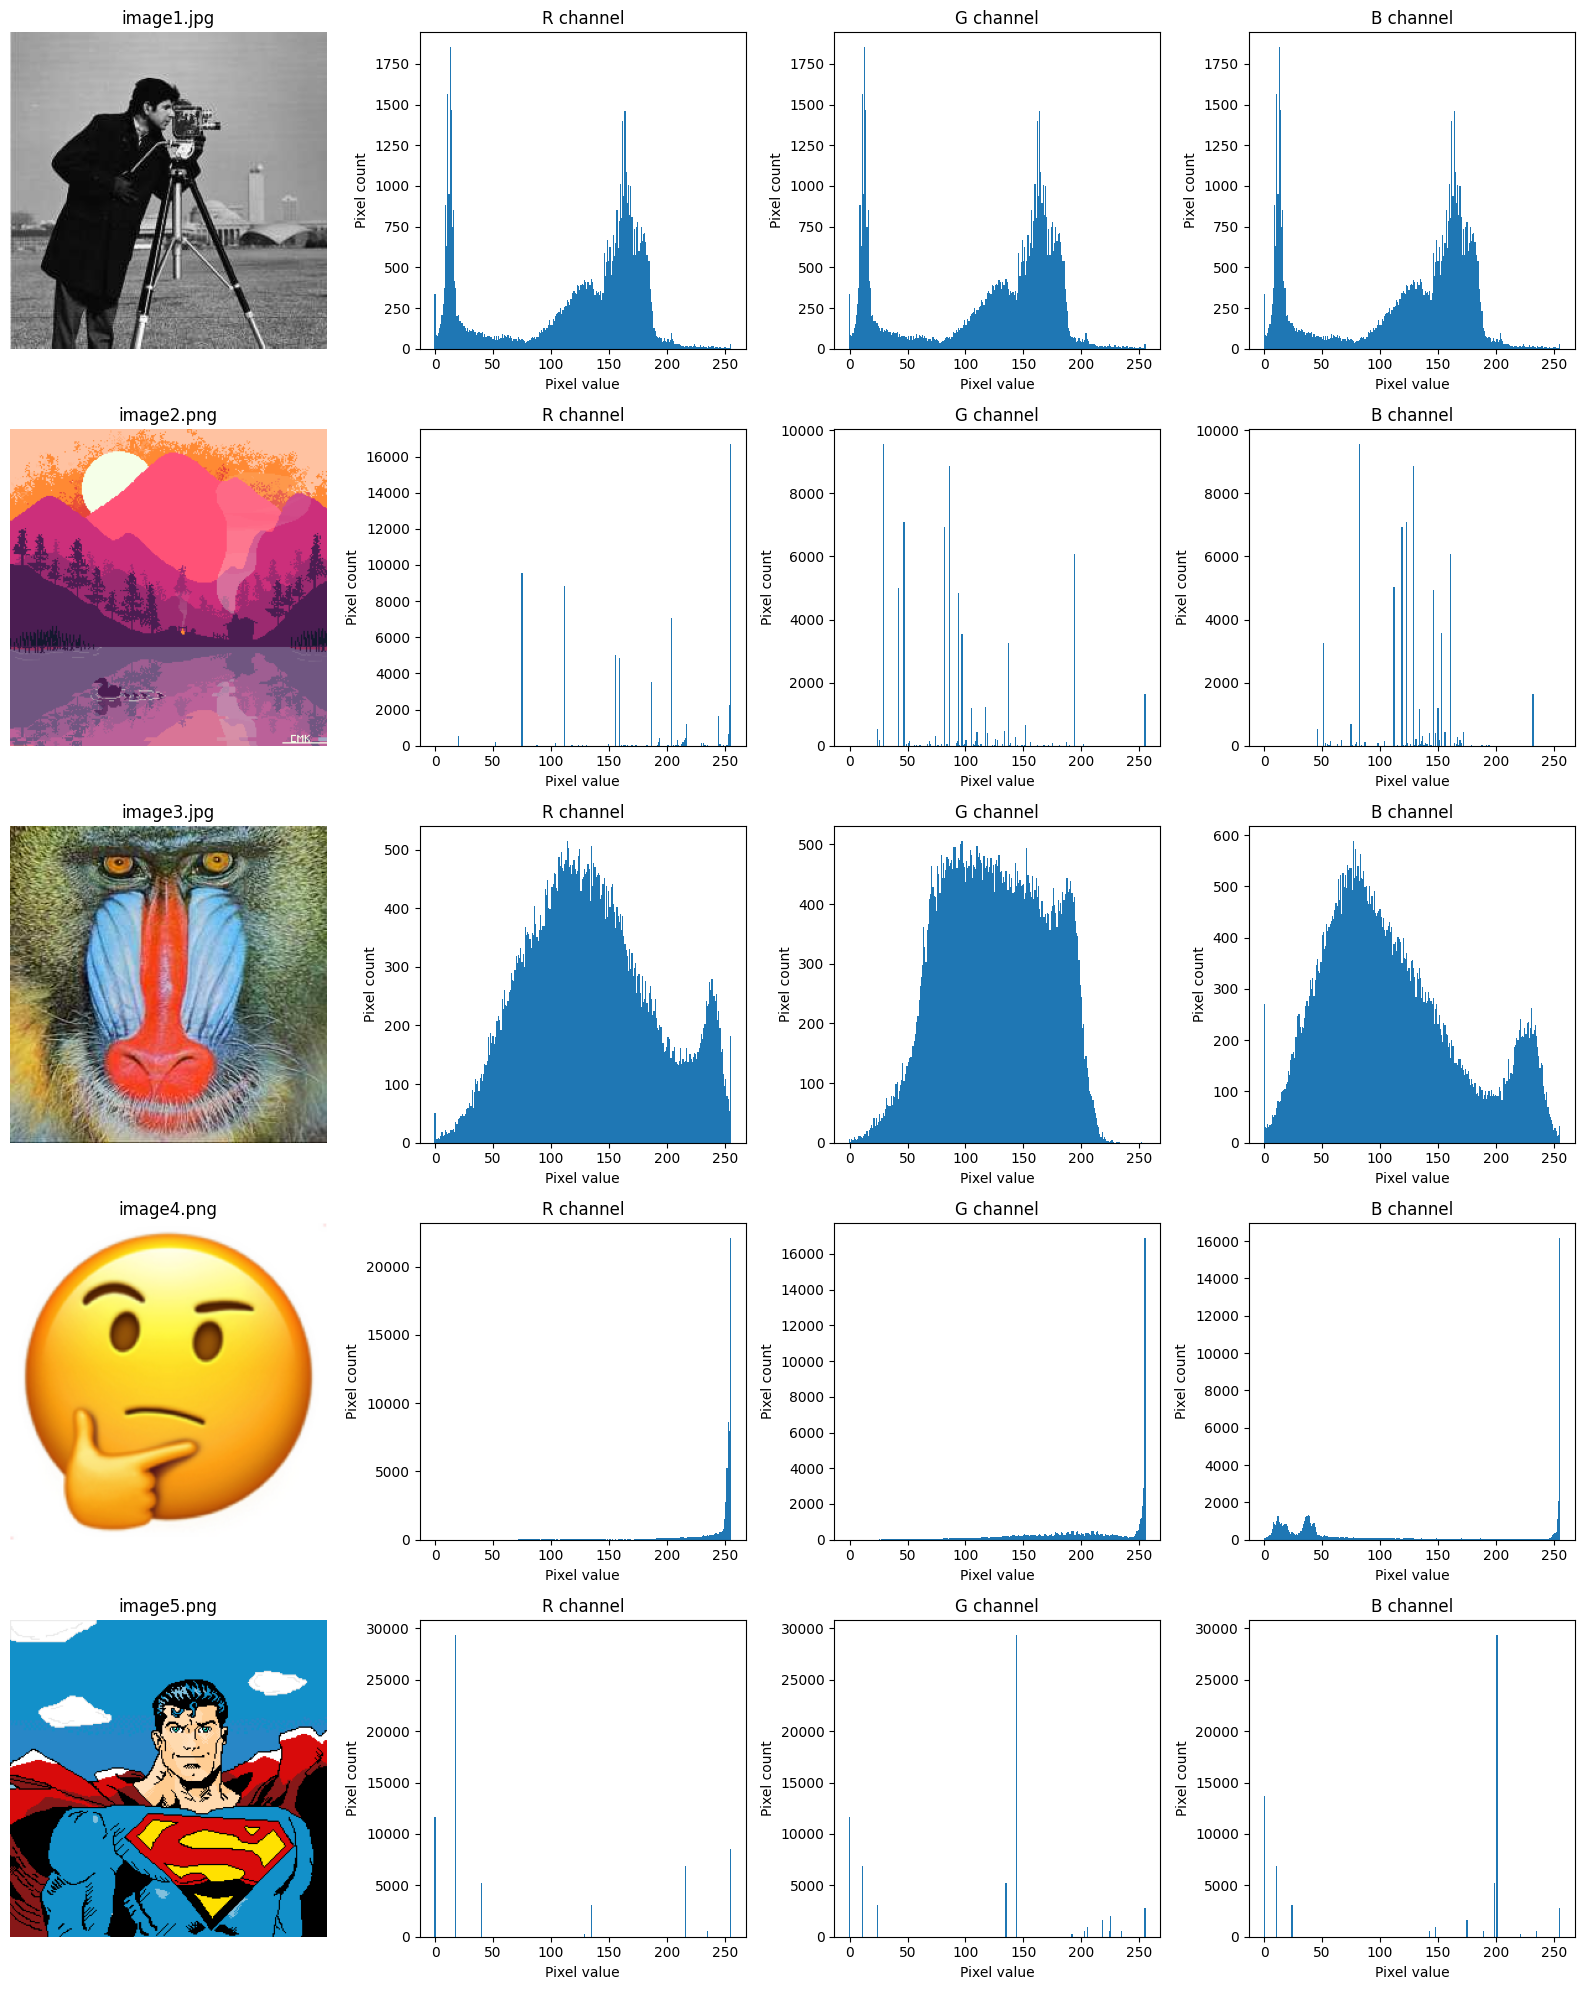

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Use the exact five image files shown in the Colab Files pane.
IMAGE_FILES = [
    "image1.jpg",
    "image2.png",
    "image3.jpg",
    "image4.png",
    "image5.png",
]

missing_files = [f for f in IMAGE_FILES if not os.path.isfile(f)]
if missing_files:
    raise FileNotFoundError(
        "The following required image files are missing from the current working directory: "
        + ", ".join(missing_files)
    )

fig, axes = plt.subplots(len(IMAGE_FILES), 4, figsize=(16, 20), squeeze=False)

for i, filename in enumerate(IMAGE_FILES):
    with Image.open(filename) as image:
        image = image.convert("RGB") # converting it to RGB
        if image.size != (256, 256):   # only 256x256!!
            raise ValueError(f"{filename} has size {image.size}; expected (256, 256).")
        image_array = np.asarray(image, dtype=np.uint8)

    axes[i, 0].imshow(image_array)
    axes[i, 0].set_title(filename)
    axes[i, 0].axis("off")

    for j, (channel_index, channel_name) in enumerate(zip(range(3), ["R", "G", "B"]), start=1):
        channel = image_array[:, :, channel_index]
        # Flatten channel to 1D, then histogram with 256 bins.
        # Bin edges are shifted by -0.5 to center each bin on an integer pixel value (0–255),
        # ensuring each bin contains exactly one discrete value.
        axes[i, j].hist(channel.ravel(), bins=np.arange(257) - 0.5, range=(-0.5, 255.5))
        axes[i, j].set_title(f"{channel_name} channel")
        axes[i, j].set_xlabel("Pixel value")
        axes[i, j].set_ylabel("Pixel count")

plt.tight_layout()
plt.show()


### Task 2 — Per-Channel Standardization of Images

Csatornánként számold ki a pixelek átlagát és szórását minden képre, majd alakítsd át ezeket 0 várható értékű, 1 szórású adathalmazzá. Ezt követően ellenőrizd a kapott adathalmaz várható értékét és szórását. **(4p)**


In [2]:
import numpy as np
from PIL import Image

# IMAGE_FILES is defined in Task 1.
standardized_images = {}

for filename in IMAGE_FILES:
    with Image.open(filename) as image:
      #  Cast to float64 before arithmetic; uint8 subtraction would wrap around.
        image_array = np.asarray(image.convert("RGB"), dtype=np.float64)

    standardized = np.empty_like(image_array, dtype=np.float64)

    print(f"\n--- {filename} ---")

    for channel_index, channel_name in enumerate(["R", "G", "B"]):
        channel = image_array[:, :, channel_index]
        mean_original = np.mean(channel)
        std_original = np.std(channel)

        print(
            f"{channel_name}: original mean = {mean_original:.6f}, "
            f"original std = {std_original:.6f}"
        )
# Guard against flat channels; division by zero is undefined.
        if np.isclose(std_original, 0.0):
            raise ValueError(
                f"{filename}, {channel_name} channel has zero standard deviation; "
                "standardization to unit variance is undefined."
            )
# Z-score normalization per channel.
        standardized[:, :, channel_index] = (channel - mean_original) / std_original
# Verify the transformation: mean ≈ 0, std ≈ 1.
        mean_standardized = np.mean(standardized[:, :, channel_index])
        std_standardized = np.std(standardized[:, :, channel_index])

        print(
            f"{channel_name}: standardized mean = {mean_standardized:.6e}, "
            f"standardized std = {std_standardized:.6f}"
        )

    standardized_images[filename] = standardized



--- image1.jpg ---
R: original mean = 118.980438, original std = 62.592165
R: standardized mean = -2.081668e-17, standardized std = 1.000000
G: original mean = 118.980438, original std = 62.592165
G: standardized mean = -2.081668e-17, standardized std = 1.000000
B: original mean = 118.980438, original std = 62.592165
B: standardized mean = -2.081668e-17, standardized std = 1.000000

--- image2.png ---
R: original mean = 179.044479, original std = 67.149374
R: standardized mean = -3.295975e-17, standardized std = 1.000000
G: original mean = 90.605408, original std = 54.326422
G: standardized mean = 3.122502e-17, standardized std = 1.000000
B: original mean = 123.029709, original std = 35.049496
B: standardized mean = 1.387779e-17, standardized std = 1.000000

--- image3.jpg ---
R: original mean = 134.253860, original std = 55.087127
R: standardized mean = 0.000000e+00, standardized std = 1.000000
G: original mean = 125.569565, original std = 44.551747
G: standardized mean = 6.938894e-1

### Task 3 — Audio Spectrograms

Olvass be két tetszőleges hangfájlt és jelenítsd meg ezek spektrogramját. **(4p)**


my_voice.wav: dtype=float64, min=-0.7940, max=0.8032
growl.wav: dtype=float64, min=-0.7537, max=0.7238


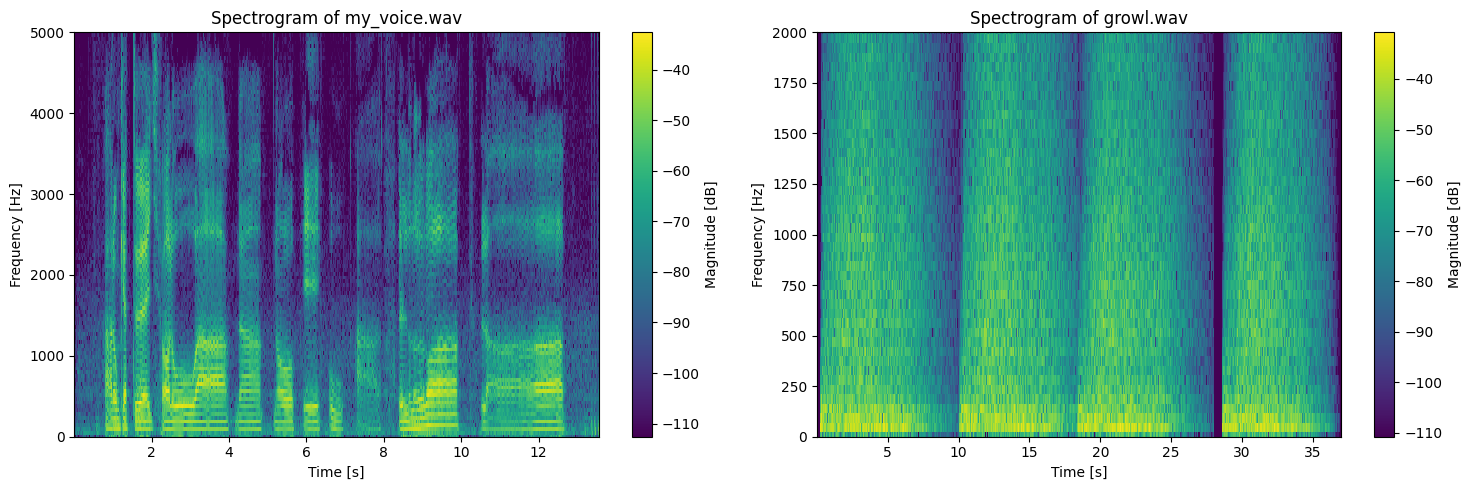

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

AUDIO_FILES = ["my_voice.wav", "growl.wav"]

# 1. Verify files exist
missing_files = [f for f in AUDIO_FILES if not os.path.isfile(f)]
if missing_files:
    raise FileNotFoundError(
        "The following required audio files are missing: " + ", ".join(missing_files)
    )

# 2. Create figure
fig, axes = plt.subplots(1, len(AUDIO_FILES), figsize=(15, 5), squeeze=False)

for i, filename in enumerate(AUDIO_FILES):
    # 3. Read audio data
    fs, data = wavfile.read(filename)

    # 4. Normalize PCM integer data to float64 in [-1.0, 1.0]
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0
    elif data.dtype == np.uint8:
        data = (data.astype(np.float64) - 128.0) / 128.0
    else:
        data = data.astype(np.float64)

    # 5. Convert stereo to mono
    if data.ndim == 2:
        data = np.mean(data, axis=1)
    elif data.ndim != 1:
        raise ValueError(f"Unsupported audio array shape for {filename}: {data.shape}")

    # 6. Remove DC offset (critical for growl files)
    data = data - np.mean(data)

    # Diagnostic print statement
    print(f"{filename}: dtype={data.dtype}, min={data.min():.4f}, max={data.max():.4f}")

    # 7. Compute spectrogram
    f, t, Sxx = signal.spectrogram(
        data,
        fs=fs,
        nperseg=1024,
        noverlap=512,
        mode="magnitude",
    )

    # 8. Convert to dB with a reasonable floor (1e-10 instead of machine epsilon)
    Sxx_dB = 20.0 * np.log10(np.maximum(Sxx, 1e-10))

    # 9. Set a standard 80 dB dynamic range for visualization
    vmax = np.max(Sxx_dB)
    vmin = vmax - 80

    # 10. Plot with explicit vmin and vmax
    mesh = axes[0, i].pcolormesh(t, f, Sxx_dB, shading="auto", vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f"Spectrogram of {filename}")
    axes[0, i].set_xlabel("Time [s]")
    axes[0, i].set_ylabel("Frequency [Hz]")

    # 11. Focus on relevant frequency range
    if "growl" in filename.lower():
        axes[0, i].set_ylim(0, 2000)
    else:
        axes[0, i].set_ylim(0, 5000)

    fig.colorbar(mesh, ax=axes[0, i], label="Magnitude [dB]")

plt.tight_layout()
plt.show()

### Task 4 — Spectrogram Standardization

Alakítsd át a spektogramokat 0 várható értékű és 1 szorású adathalmazzá. Ezt követően ellenőrizd a kapott adathalmaz várható értékét és szórását. **(4p)**


In [4]:
import numpy as np
from scipy.io import wavfile
from scipy import signal
import os

AUDIO_FILES = ["my_voice.wav", "growl.wav"]
missing_files = [f for f in AUDIO_FILES if not os.path.isfile(f)]
if missing_files:
    raise FileNotFoundError(f"Missing files: {missing_files}")

standardized_spectrograms = {}

for filename in AUDIO_FILES:
    # Load and normalize audio
    fs, data = wavfile.read(filename)
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0
    elif data.dtype == np.uint8:
        data = (data.astype(np.float64) - 128.0) / 128.0
    else:
        data = data.astype(np.float64)

    if data.ndim == 2:
        data = np.mean(data, axis=1)

    data = data - np.mean(data)

    # Compute spectrogram
    f, t, Sxx = signal.spectrogram(data, fs=fs, nperseg=1024, noverlap=512, mode="magnitude")

    # Calculate original statistics
    mu_orig = np.mean(Sxx)
    std_orig = np.std(Sxx)
    print(f"\n--- {filename} ---")
    print(f"Original spectrogram: mean = {mu_orig:.6e}, std = {std_orig:.6e}")

    if np.isclose(std_orig, 0.0):
        raise ValueError(f"Zero variance in spectrogram for {filename}.")

    # Standardize
    Sxx_norm = (Sxx - mu_orig) / std_orig
    standardized_spectrograms[filename] = Sxx_norm

    # Verify
    mu_norm = np.mean(Sxx_norm)
    std_norm = np.std(Sxx_norm)
    print(f"Standardized spectrogram: mean = {mu_norm:.10e}, std = {std_norm:.10f}")


--- my_voice.wav ---
Original spectrogram: mean = 7.667339e-05, std = 5.187416e-04
Standardized spectrogram: mean = 2.7200185706e-17, std = 1.0000000000

--- growl.wav ---
Original spectrogram: mean = 1.135795e-04, std = 6.322115e-04
Standardized spectrogram: mean = -1.7562892391e-17, std = 1.0000000000


### Task 5 — Web-Page Text and Letter Frequency

Python scriptből töltsd le a http://smartlab.tmit.bme.hu/oktatas-deep-learning oldal szöveges tartalmát, jelenítsd meg a szöveges tartalmat, továbbá hisztogramon jelenítsd meg a tartalomban a betűk előfordulásának gyakoriságát. **(4p)**


TLS certificate verification failed for http://smartlab.tmit.bme.hu/oktatas-deep-learning.
Retrying with certificate verification disabled.
Downloaded page: https://smartlab.tmit.bme.hu/oktatas-deep-learning
EXTRACTED TEXT CONTENT
Deep Learning a gyakorlatban Python és LUA alapon - VITMAV45 | SmartLab, BME TMIT
Languages
Magyar
English
Menü be/kikapcsolás
RÓLUNK
Laborunkról
Munkatársaink
Média megjelenések
MEGOLDÁSAINK
Profivox magyar nyelvű felolvasó (korpuszos)
Profivox magyar nyelvű felolvasó (DNN)
Profivox magyar nyelvű felolvasó (HMM)
Profivox magyar nyelvű felolvasó (diádos,triádos)
StrokeAid
Alkalmazások
Jaws for Windows integráció
Időjárás mindenkinek (magyar, Windows 8)
AALFred (5 nyelven, Windows 8.1)
Robobraille
Beszélő ATM-ek
Gyógyszervonal (OGYI)
Árlista felolvasó (T-mobile)
Keleti pályaudvar bemondórendszere
Mindenség elmélete c. film gépi beszéd szinkron
K+F
Kutatási projektek (folyamatban)
Kutatási projektek (befejezett)
Publikációk (összes)
Publikációk (kiemelt)
Letölt

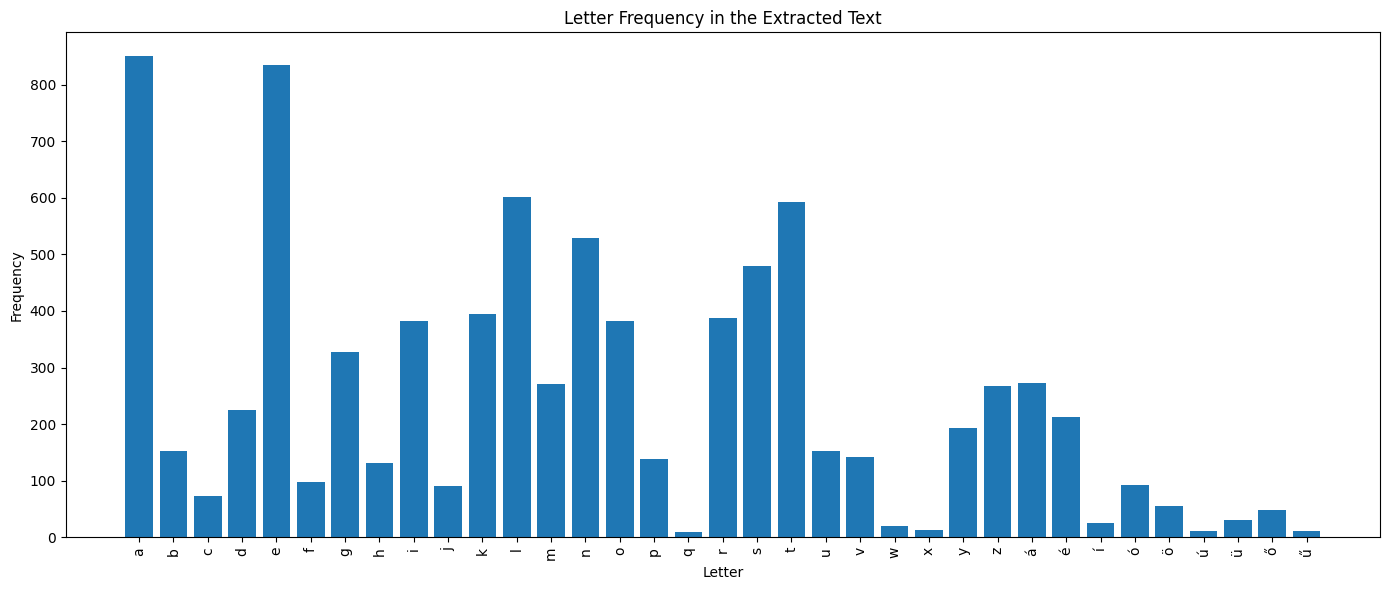

In [5]:
import re
import requests
import urllib3
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from collections import Counter

REQUESTED_URL = "http://smartlab.tmit.bme.hu/oktatas-deep-learning"
FALLBACK_URL = "https://smartlab.tmit.bme.hu/oktatas"

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0"
})


def download_page(url):
    """
    Download a webpage.
    First attempt: normal TLS certificate verification.
    If certificate verification fails: retry without certificate verification.
    """
    try:
        response = session.get(
            url,
            timeout=20,
            allow_redirects=True
        )
        response.raise_for_status()
        return response

    except requests.exceptions.SSLError as error:
        print(f"TLS certificate verification failed for {url}.")
        print("Retrying with certificate verification disabled.")

        urllib3.disable_warnings(
            urllib3.exceptions.InsecureRequestWarning
        )

        response = session.get(
            url,
            timeout=20,
            allow_redirects=True,
            verify=False
        )
        response.raise_for_status()
        return response



try:
    response = download_page(REQUESTED_URL)
    source_url = response.url

except requests.RequestException as first_error:
    print(f"Requested URL failed: {first_error}")
    print(f"Trying fallback URL: {FALLBACK_URL}")

    try:
        response = download_page(FALLBACK_URL)
        source_url = response.url

    except requests.RequestException as second_error:
        raise ConnectionError(
            "Neither the requested URL nor the fallback URL could be downloaded.\n"
            f"Requested URL error: {first_error}\n"
            f"Fallback URL error: {second_error}"
        ) from second_error


print(f"Downloaded page: {source_url}")


# 2. Extract textual content

response.encoding = response.apparent_encoding or response.encoding

soup = BeautifulSoup(response.text, "html.parser")

# Remove non-visible/non-text elements.
for element in soup(["script", "style", "noscript"]):
    element.decompose()

page_text = soup.get_text(separator="\n")

# Clean excessive whitespace.
page_text = re.sub(r"[ \t]+", " ", page_text)
page_text = "\n".join(
    line.strip()
    for line in page_text.splitlines()
    if line.strip()
)

# 3. Display the extracted text


print("=" * 80)
print("EXTRACTED TEXT CONTENT")
print("=" * 80)
print(page_text)
print("=" * 80)


# 4. Count letter frequencies

# isalpha() correctly includes Unicode letters,
letters = [
    character.lower()
    for character in page_text
    if character.isalpha()
]

letter_counts = Counter(letters)

letters_sorted = sorted(letter_counts.keys())
frequencies = [
    letter_counts[letter]
    for letter in letters_sorted
]

# 5. Plot the histogram

plt.figure(figsize=(14, 6))

plt.bar(
    letters_sorted,
    frequencies
)

plt.title("Letter Frequency in the Extracted Text")
plt.xlabel("Letter")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()